In [ ]:
#step1: import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#step2:loading the dataset
import os
import pandas as pd

# ---------- Universal Dataset Loader ----------

def load_data(filename):
    possible_paths = [
        filename,                      # same folder
        f"data/{filename}",            # project/data folder
        f"/content/{filename}",        # Colab direct upload
        f"/content/data/{filename}"    # Colab data folder
    ]

    for path in possible_paths:
        if os.path.exists(path):
            print(f"Loaded file from: {path}")
            return pd.read_csv(path)

    raise FileNotFoundError("Dataset not found in any expected location.")

# Load dataset
df = load_data("heart.csv")

Loaded file from: heart.csv


In [ ]:
#step3: EDA
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.shape

(303, 14)

In [ ]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
#step4: data cleaning
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

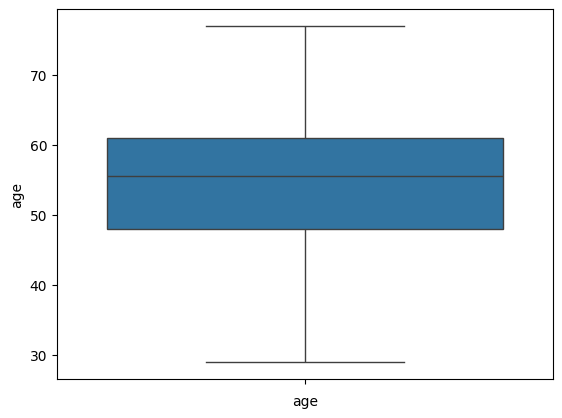

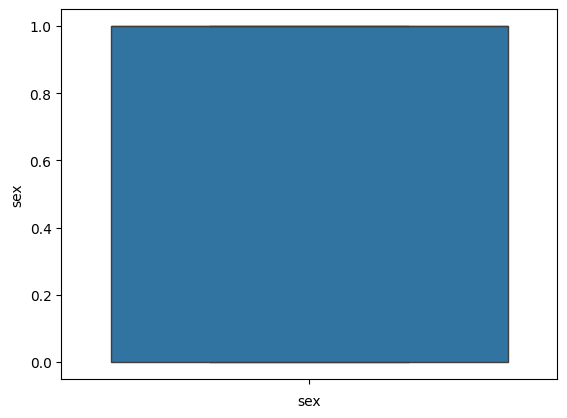

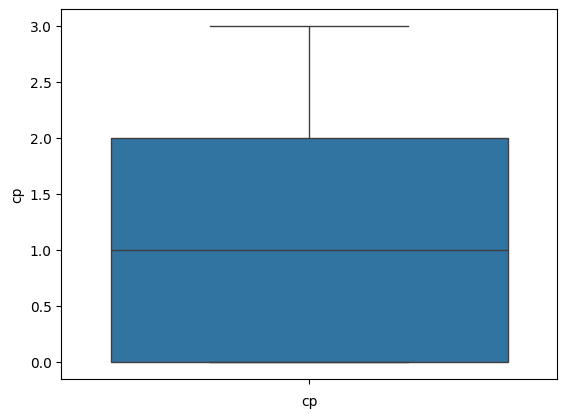

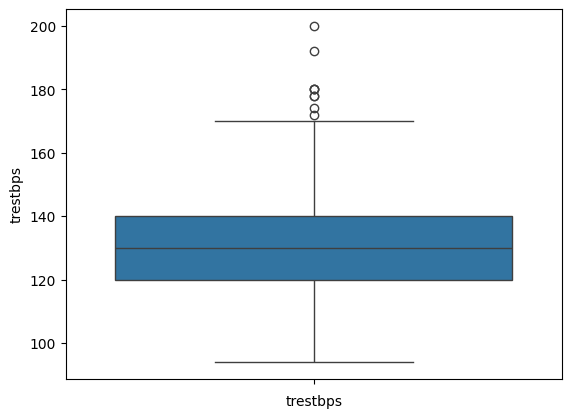

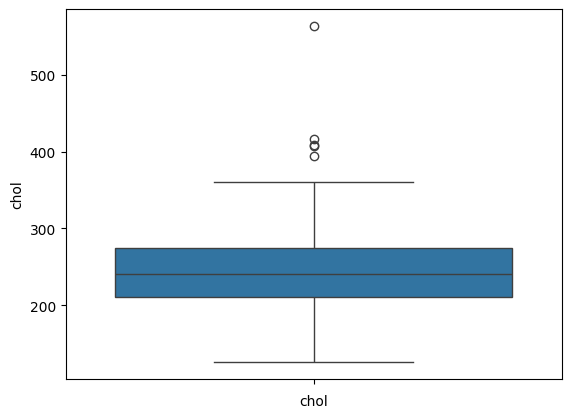

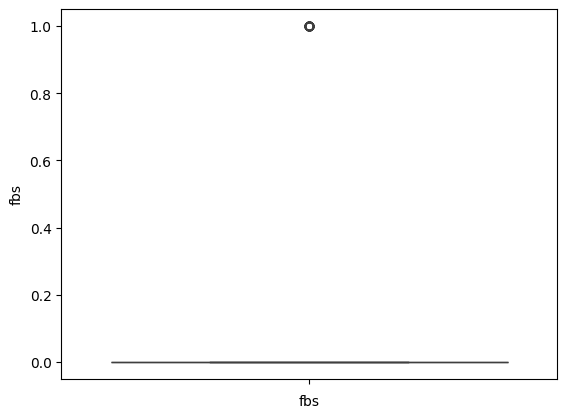

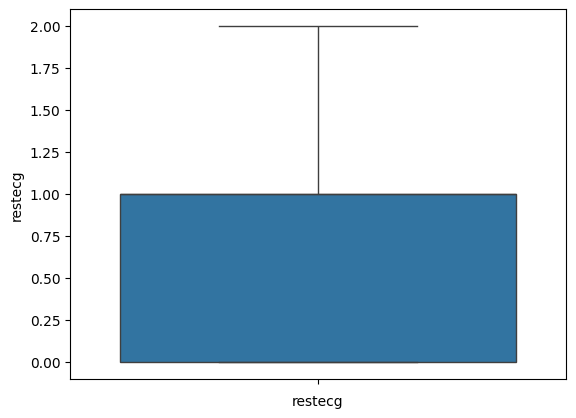

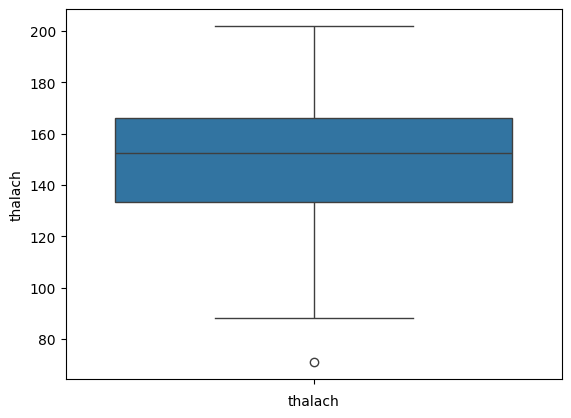

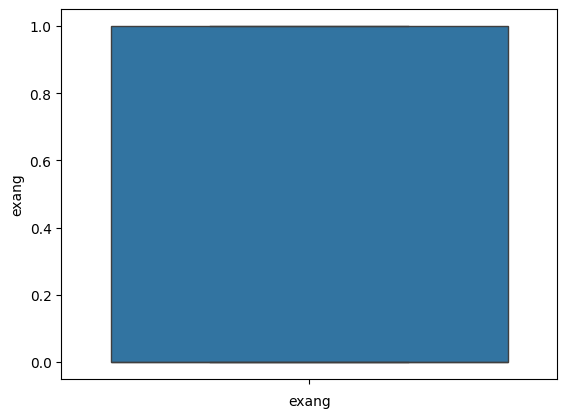

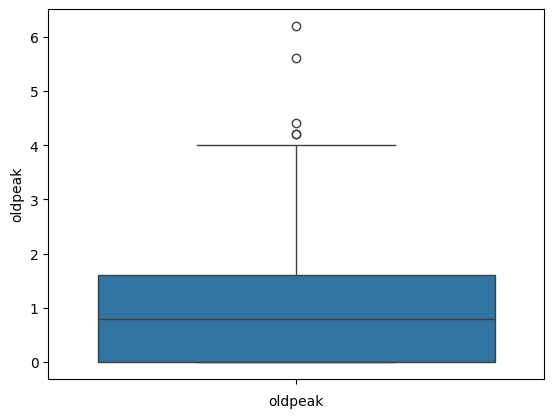

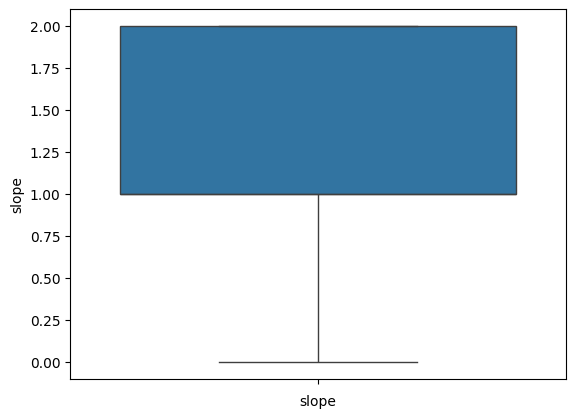

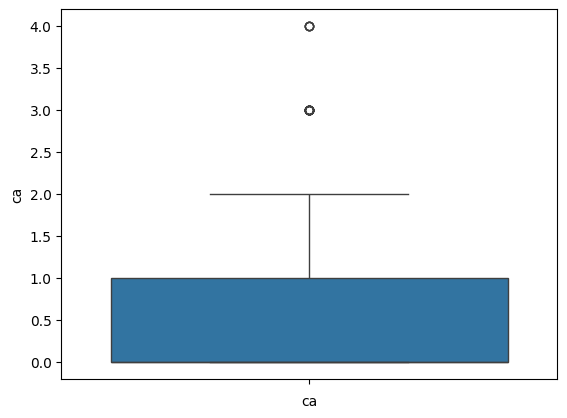

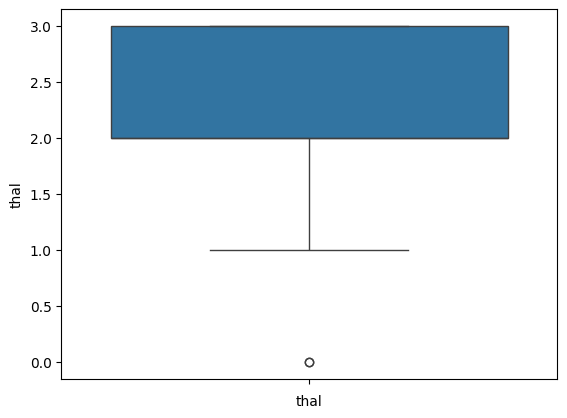

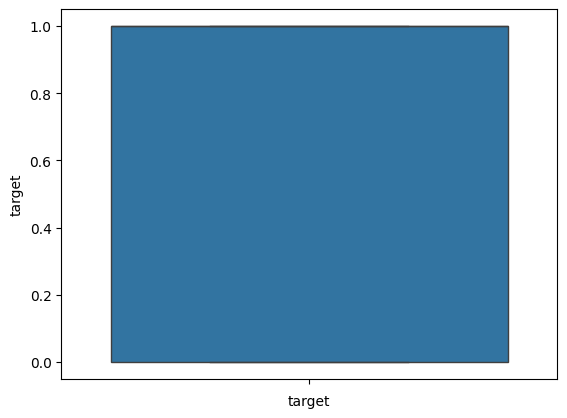

In [ ]:
# step5: check for outliers

col = list(df.columns)

for col in df.columns:
    if df[col].dtype != 'object':
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()


<Axes: >

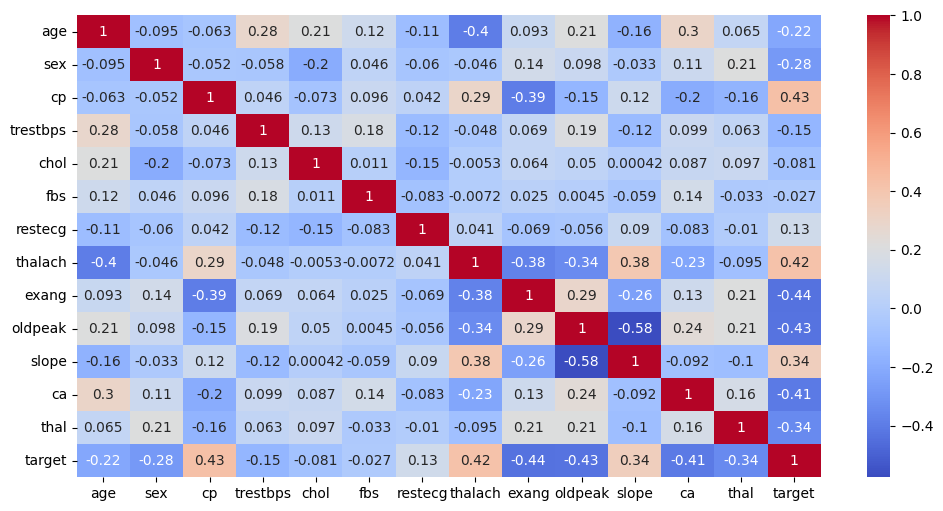

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
# step 5 - model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
x=df.drop('target',axis=1)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y=df['target']
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
np.random.seed(42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=38)

In [ ]:
y_test

,target
167,0
91,1
134,1
80,1
103,1
...,...
73,1
118,1
8,1
58,1


In [ ]:
model  = DecisionTreeClassifier()

In [ ]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(x_test)


In [ ]:
y_pred

array([0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
# dataframe actual and prediction
comparision=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
comparision

,Actual,Predicted
167,0,0
91,1,0
134,1,1
80,1,1
103,1,0
...,...,...
73,1,1
118,1,1
8,1,1
58,1,1


In [ ]:
accuracy_score(y_test,y_pred)

0.8032786885245902

In [ ]:
cm  = confusion_matrix(y_pred, y_test)
cm

array([[23,  7],
       [ 5, 26]])

[Text(0.5492788461538461, 0.95, 'x[2] <= 0.5\ngini = 0.496\nsamples = 241\nvalue = [110, 131]'),
 Text(0.3581730769230769, 0.85, 'x[11] <= 0.5\ngini = 0.406\nsamples = 113\nvalue = [81, 32]'),
 Text(0.45372596153846156, 0.8999999999999999, 'True  '),
 Text(0.23557692307692307, 0.75, 'x[12] <= 2.5\ngini = 0.499\nsamples = 55\nvalue = [26.0, 29.0]'),
 Text(0.10576923076923077, 0.65, 'x[8] <= 0.5\ngini = 0.36\nsamples = 34\nvalue = [8, 26]'),
 Text(0.038461538461538464, 0.55, 'x[7] <= 96.5\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.019230769230769232, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.057692307692307696, 0.45, 'x[4] <= 316.5\ngini = 0.091\nsamples = 21\nvalue = [1, 20]'),
 Text(0.038461538461538464, 0.35, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.07692307692307693, 0.35, 'x[4] <= 362.0\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.057692307692307696, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.09615384615384616, 0.25, 'g

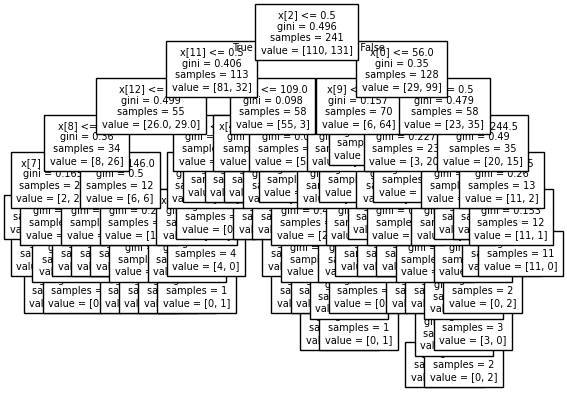

In [ ]:
from sklearn import tree
tree.plot_tree(model, fontsize = 7)

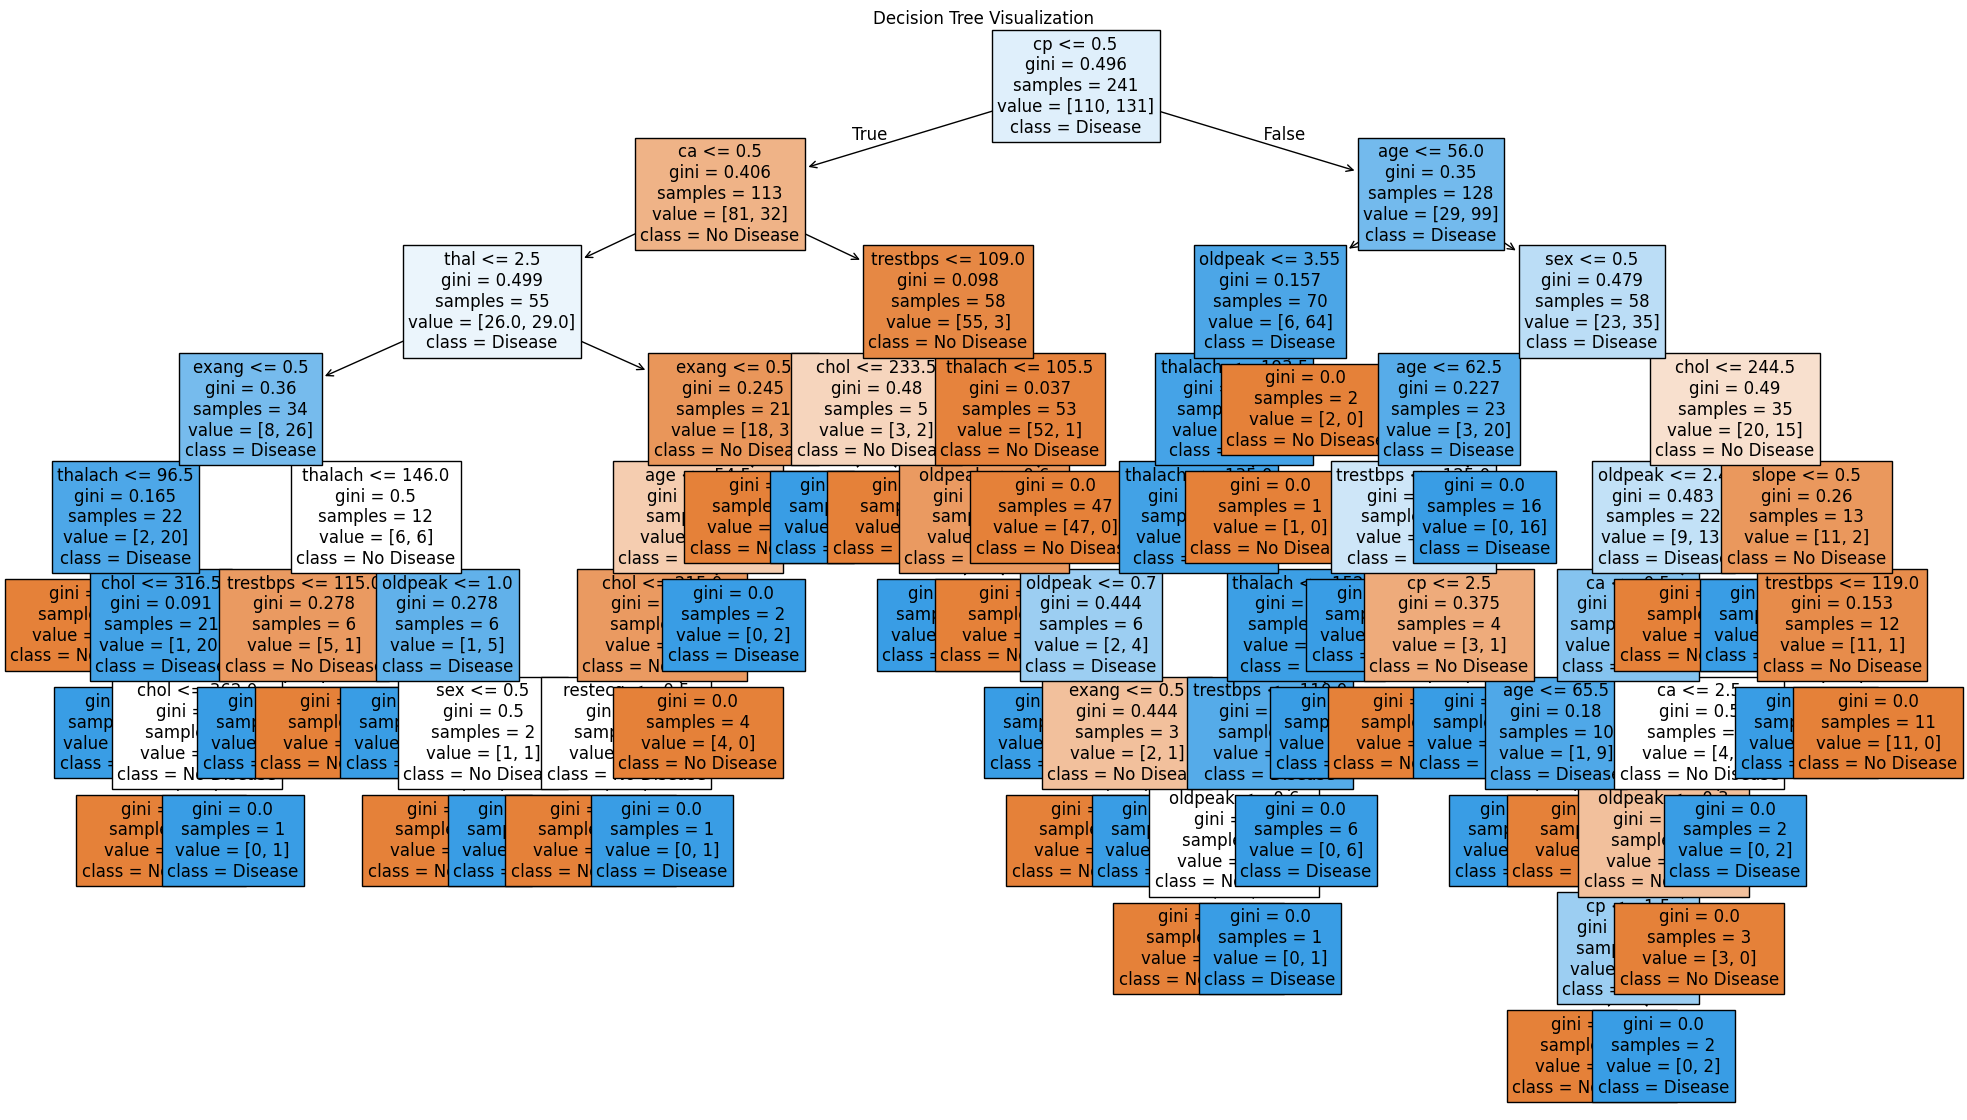

In [ ]:
#visual map showing how the decision tree makes predictions.
plt.figure(figsize=(24,14))

tree.plot_tree(
    model,
    feature_names=x_train.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    fontsize=12
)

plt.title("Decision Tree Visualization", fontsize=12)
plt.show()

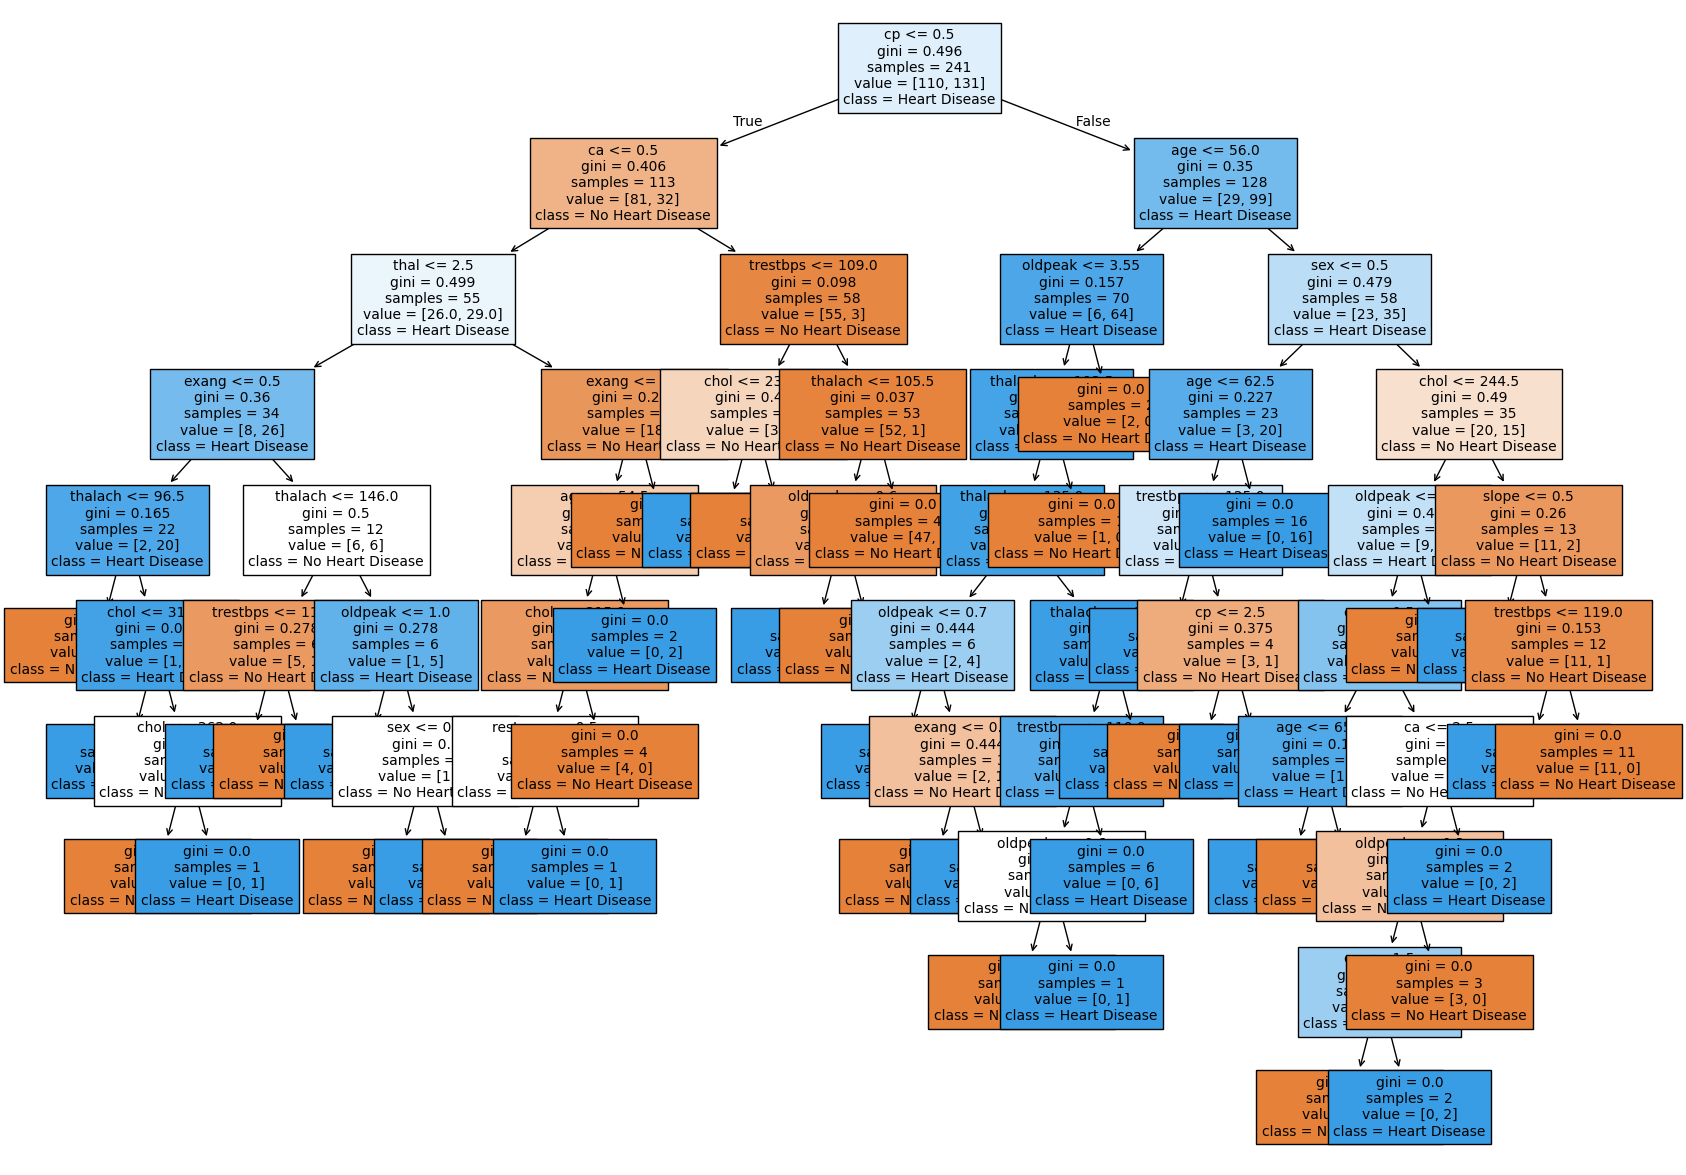

In [ ]:
# visual map showing how the decision tree predicts heart disease.
from sklearn import tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
tree.plot_tree(model, feature_names=x_train.columns, filled=True, class_names=['No Heart Disease', 'Heart Disease'], fontsize = 10)
plt.show()

In [ ]:
# Hyperparameter Tuning (Decision Tree)
#Decision Tree Depth vs Accuracy
depths = [1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
    model = DecisionTreeClassifier(max_depth=i, random_state=60)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Max Depth: {i} | Accuracy: {acc:.3f}")

Max Depth: 1 | Accuracy: 0.803
Max Depth: 2 | Accuracy: 0.803
Max Depth: 3 | Accuracy: 0.820
Max Depth: 4 | Accuracy: 0.803
Max Depth: 5 | Accuracy: 0.836
Max Depth: 6 | Accuracy: 0.836
Max Depth: 7 | Accuracy: 0.803
Max Depth: 8 | Accuracy: 0.836
Max Depth: 9 | Accuracy: 0.820
Max Depth: 10 | Accuracy: 0.820
Max Depth: 11 | Accuracy: 0.820
Max Depth: 12 | Accuracy: 0.820
Max Depth: 13 | Accuracy: 0.820


In [ ]:
model.get_depth()

9

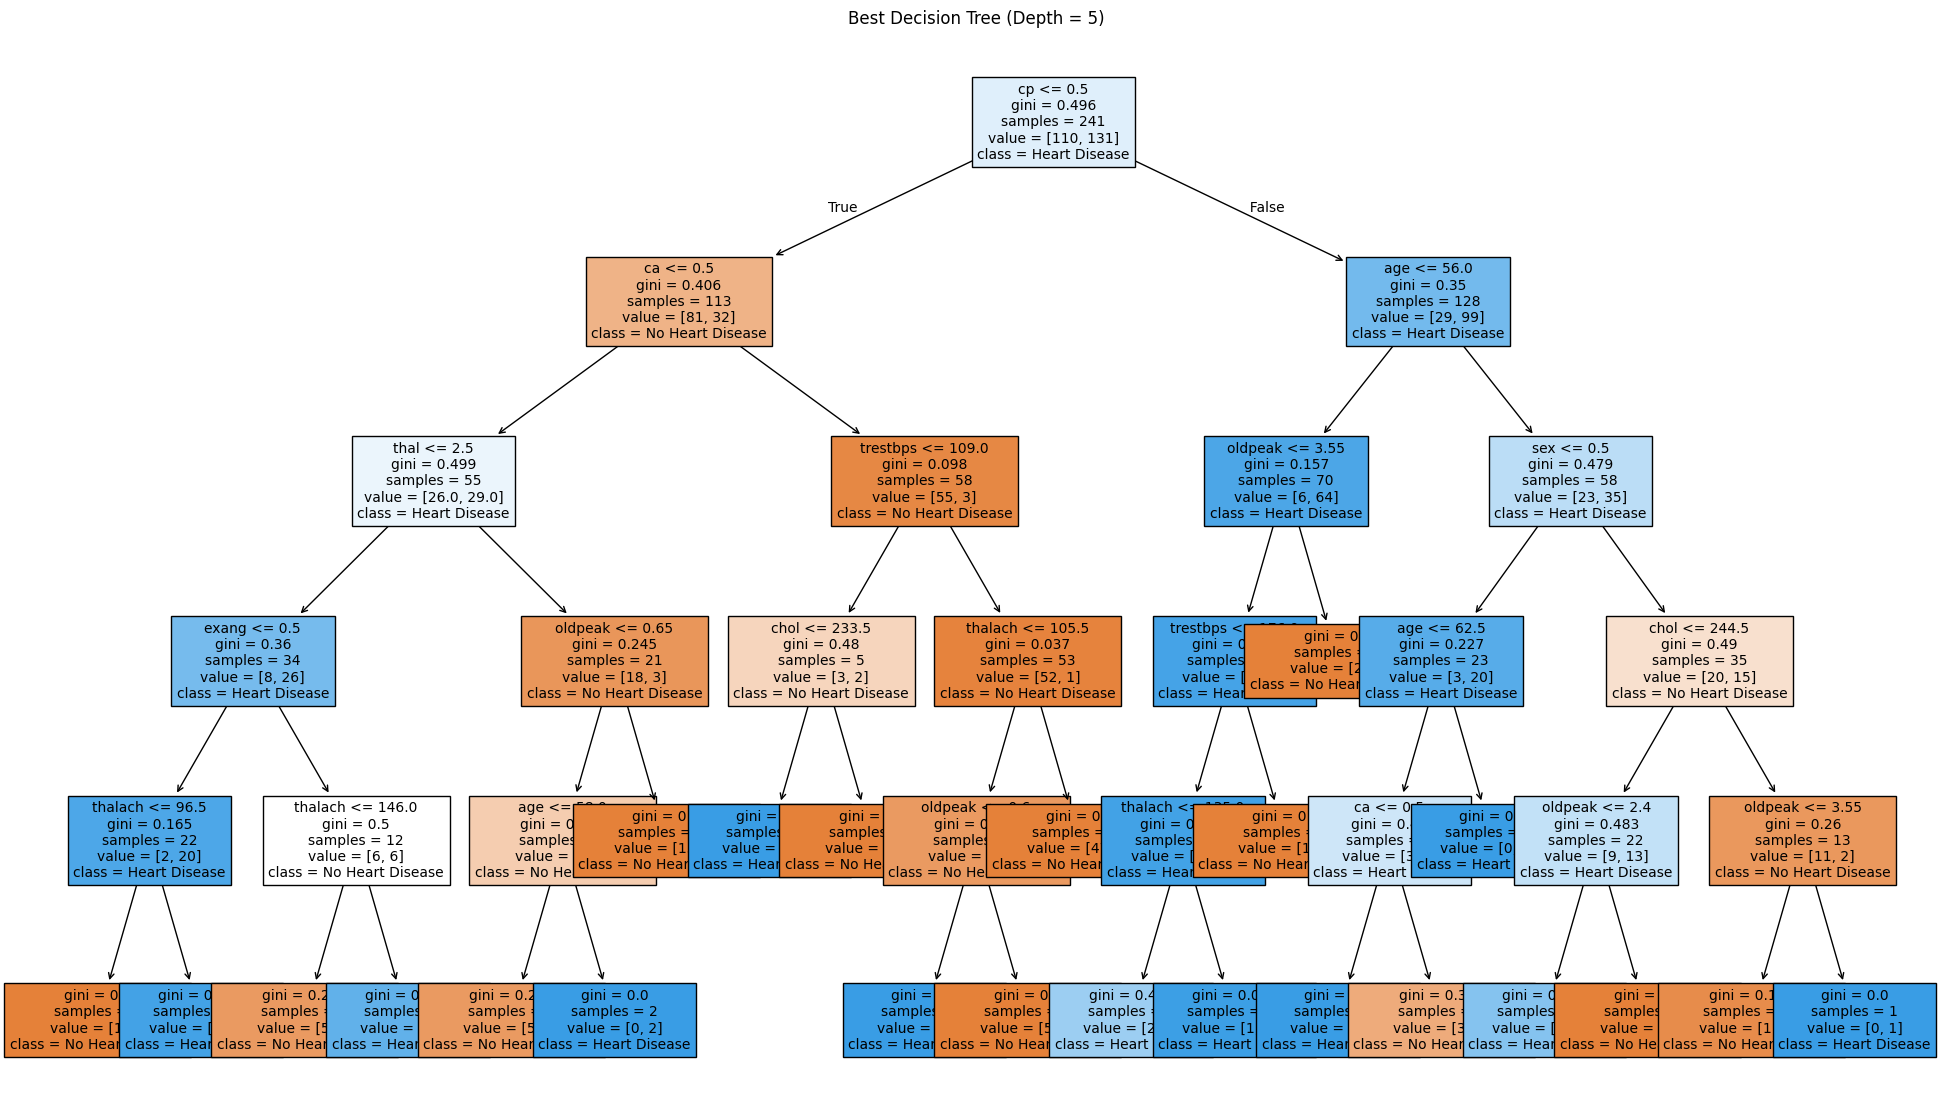

In [ ]:
#Choose simplest model that gives highest accuracy.
best_model = DecisionTreeClassifier(max_depth=5, random_state=60)
best_model.fit(x_train, y_train)

plt.figure(figsize=(24,14))
plot_tree(best_model,
          feature_names=x_train.columns,
          filled=True,
          class_names=['No Heart Disease','Heart Disease'],
          fontsize=10)

plt.title("Best Decision Tree (Depth = 5)")
plt.show()

**Hyperparameter Tuning using GridSearchCV**


Finds the best combination of parameters for Decision Tree automatically

In [ ]:
# Hyperparameter Tuning (Grid Search)

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Create a Decision Tree model (base model)

new_model = DecisionTreeClassifier()

In [ ]:
# Define parameter combinations to test

grid_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 5, 50, 100],
    'random_state': [0, 1, 2, 40, 41, 42],
    'min_samples_split': [2, 3, 5, 6, 8, 9, 22],
    'min_samples_leaf': [1, 4, 6, 7, 9, 10],
    'max_features': [1, 2, 3, 4, 5, 6, 10]
}

In [ ]:
# Grid Search with Cross Validation

gv = GridSearchCV(
    estimator=new_model,
    param_grid=grid_params,
    cv=3
)

gv.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 5, 50, 100],
                         'max_features': [1, 2, 3, 4, 5, 6, 10],
                         'min_samples_leaf': [1, 4, 6, 7, 9, 10],
                         'min_samples_split': [2, 3, 5, 6, 8, 9, 22],
                         'random_state': [0, 1, 2, 40, 41, 42]})

In [ ]:
# Best parameter combination

gv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 3,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'random_state': 41}

In [ ]:
# Get best model from grid search

dt_model = gv.best_estimator_

# Predict test data
y_pred1 = dt_model.predict(x_test)

# Accuracy
accuracy_score(y_test, y_pred1)

0.819672131147541

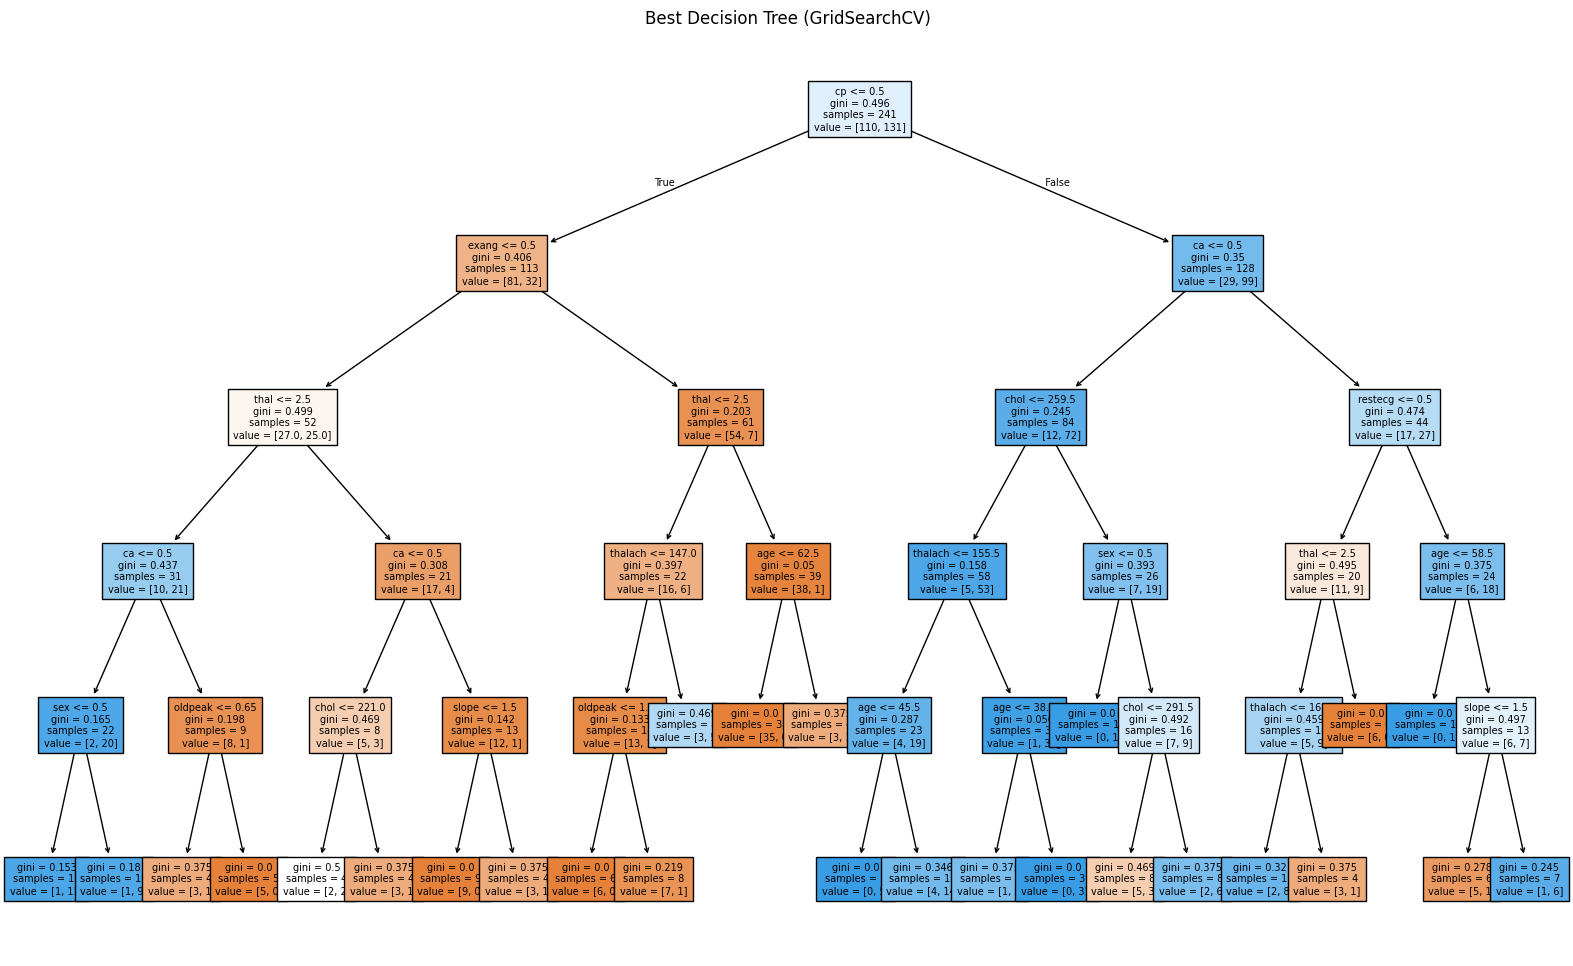

In [ ]:
#Visualize Best Decision Tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,12))

tree.plot_tree(dt_model,
               feature_names=x_train.columns,
               filled=True,
               fontsize=7)

plt.title("Best Decision Tree (GridSearchCV)")
plt.show()

**Hyperparameter Tuning using RandomizedSearchCV**


Tests random parameter combinations instead of all combinations and Much faster than GridSearch

In [ ]:
#Import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#Create Model
new_model1 = DecisionTreeClassifier()

In [ ]:
#Parameter Distribution
param_dict = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 5, 50, 100],
    'random_state': [0, 1, 2, 40, 41, 42],
    'min_samples_split': [2, 3, 5, 6, 8, 9, 22],
    'min_samples_leaf': [1, 4, 6, 7, 9, 10],
    'max_features': [1, 2, 3, 4, 5, 6, 10]
}

In [ ]:
#Run Randomized Search
rv = RandomizedSearchCV(
    estimator=new_model1,
    param_distributions=param_dict,
    cv=3,
    random_state=42,
    n_jobs=1
)

rv.fit(x_train, y_train)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 5, 50, 100],
                                        'max_features': [1, 2, 3, 4, 5, 6, 10],
                                        'min_samples_leaf': [1, 4, 6, 7, 9, 10],
                                        'min_samples_split': [2, 3, 5, 6, 8, 9,
                                                              22],
                                        'random_state': [0, 1, 2, 40, 41, 42]},
                   random_state=42)

In [ ]:
#Evaluate Randomized Model
dt_model1 = rv.best_estimator_

y_pred2 = dt_model1.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))

Accuracy: 0.8524590163934426


In [ ]:
# Best depth model prediction

best_model = DecisionTreeClassifier(max_depth=5, random_state=60)
best_model.fit(x_train, y_train)

y_pred_best = best_model.predict(x_test)

In [ ]:
#Model Accuracy Comparison
print("\nModel Accuracy Comparison\n")

print("Default Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred))

print("Best Depth Model Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("GridSearchCV Accuracy:",
      accuracy_score(y_test, y_pred1))

print("RandomizedSearchCV Accuracy:",
      accuracy_score(y_test, y_pred2))


Model Accuracy Comparison

Default Decision Tree Accuracy: 0.819672131147541
Best Depth Model Accuracy: 0.8360655737704918
GridSearchCV Accuracy: 0.819672131147541
RandomizedSearchCV Accuracy: 0.8524590163934426



## Conclusion

### Project Overview
- Heart disease prediction was performed using a Decision Tree model.
- Data analysis, visualization, model building, and optimization were completed.

### Data Analysis & Visualization
- Dataset explored using statistical summary and correlation heatmap.
- Boxplots helped identify data distribution and potential outliers.
- Feature relationships were analyzed before model training.

### Model Building
- Dataset split into training and testing sets.
- Initial Decision Tree model achieved accuracy ≈ **0.80**.

### Hyperparameter Tuning
- Different `max_depth` values were tested to improve performance.
- Best accuracy obtained at **max_depth = 5**.
- GridSearchCV tested all parameter combinations for optimal results.
- RandomizedSearchCV provided faster optimization with similar performance.

### Model Performance
- Best model accuracy: **0.836 (83.6%)**.
- Tuned model performed better than the default model.

### Observations
- Increasing depth initially improved accuracy.
- Higher depths increased model complexity without performance gain.
- Very deep trees indicate risk of **overfitting**.
- Simpler models provided stable and interpretable predictions.

### Key Learnings
- Hyperparameter tuning improves model performance.
- Model complexity should be controlled to avoid overfitting.
- Decision Trees are interpretable and useful for classification problems.
